In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
appeareances = pd.read_excel("C:\\Users\\DIVYAM\\OneDrive\\Desktop\\c10project1\\appearances.xlsx")
appeareances.head(1)

,appearance_id,game_id,player_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2224728_119169,2224728,119169,2012-07-13,Aron Johannsson,DK1,0,0,0,0,90


In [3]:
appeareances.shape

(3568, 11)

In [4]:
appeareances.isnull().sum()

appearance_id     0
game_id           0
player_id         0
date              0
player_name       0
competition_id    0
yellow_cards      0
red_cards         0
goals             0
assists           0
minutes_played    0
dtype: int64

In [5]:
appeareances.dtypes

appearance_id             object
game_id                    int64
player_id                  int64
date              datetime64[ns]
player_name               object
competition_id            object
yellow_cards               int64
red_cards                  int64
goals                      int64
assists                    int64
minutes_played             int64
dtype: object

In [6]:
appeareances.isnull().sum()

appearance_id     0
game_id           0
player_id         0
date              0
player_name       0
competition_id    0
yellow_cards      0
red_cards         0
goals             0
assists           0
minutes_played    0
dtype: int64

In [7]:
conti_appeareances = appeareances.select_dtypes(include = "number")
conti_appeareances
categ_appeareances = appeareances.select_dtypes(exclude = "number")
categ_appeareances

,appearance_id,date,player_name,competition_id
0,2224728_119169,2012-07-13,Aron Johannsson,DK1
1,2224732_161244,2012-07-14,Conor O'Brien,DK1
2,2224729_39467,2012-07-15,Clarence Goodson,DK1
3,2232104_119169,2012-07-19,Aron Johannsson,ELQ
4,2219794_39475,2012-07-22,Sacha Kljestan,BESC
...,...,...,...,...
3563,3415291_537467,2020-09-26,Joseph Efford,BE1
3564,3415296_367423,2020-09-26,Chris Durkin,BE1
3565,3431983_478940,2020-09-26,Reggie Cannon,PO1
3566,3450575_361104,2020-09-26,Sergino Dest,NL1


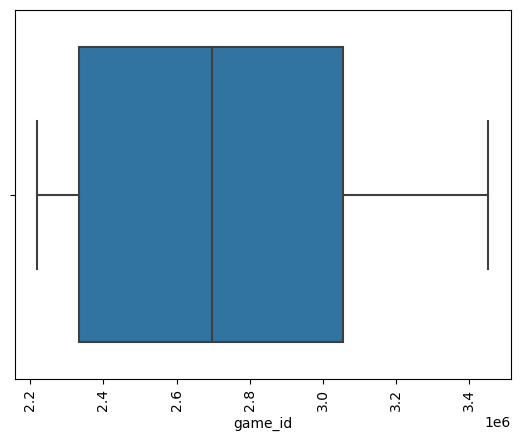

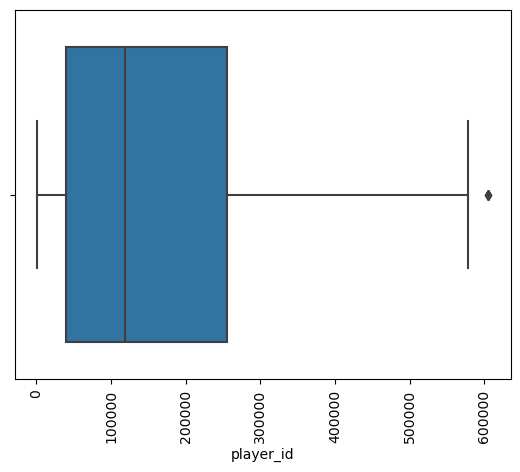

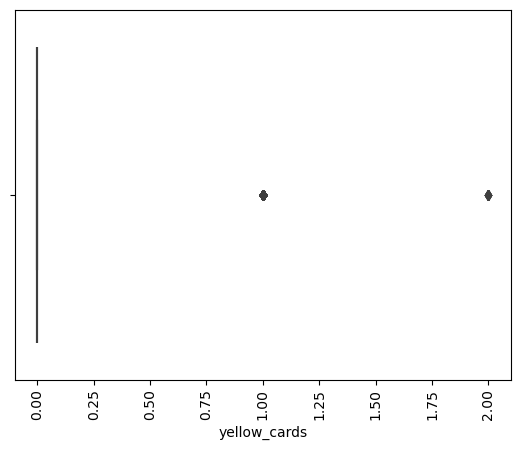

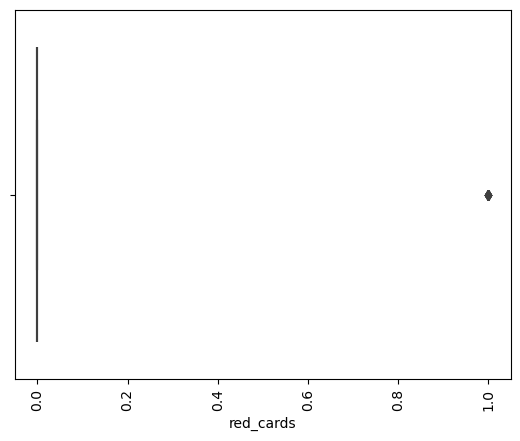

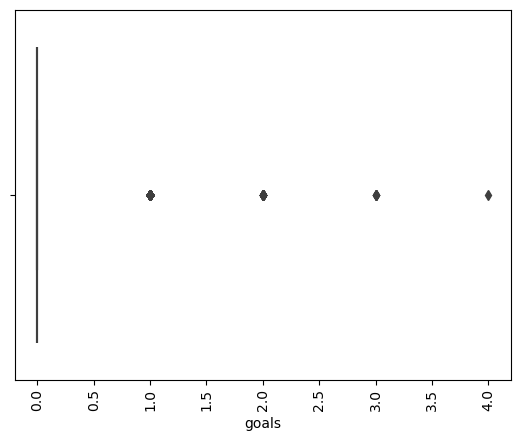

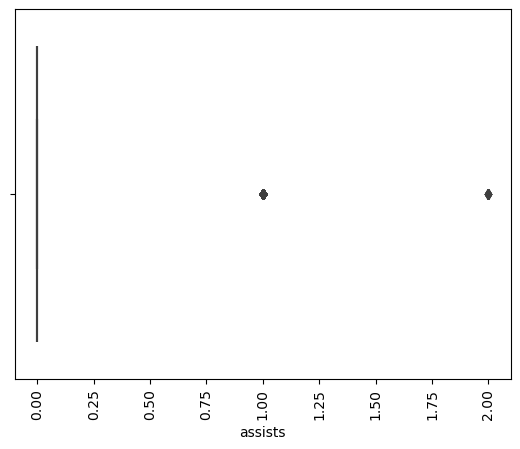

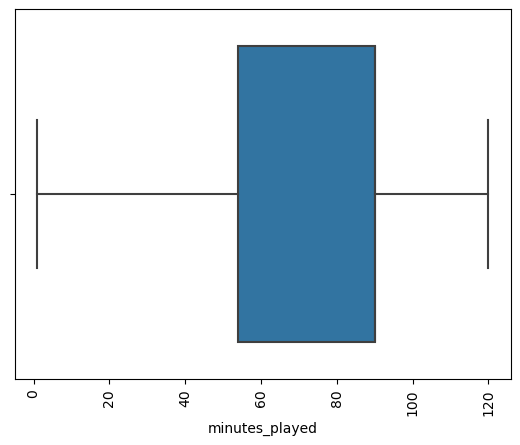

In [8]:
for a in conti_appeareances.columns:
    sns.boxplot(x=conti_appeareances[a])
    plt.xticks(rotation=90)
    plt.show()

We cannot perform outlier treatment on this dataset:
 1. Player_id- it is a unique identifier given to every player so we cannot make 2 players ids same.
 2. Yellow cards and red cards cannot be treated because they are given to those players by the refree in the game who fouls deliberately so we cannot      remove them.
 3. Goals and assists cannot be treated because the number of goals and assists are unique as they are performed by the players in the match so we          cannot increase or decrease someone's goals or assists(last pass given by one player which helped the other player to score the goal or made the        finisher move).   

In [9]:
conti_appeareances.columns

Index(['game_id', 'player_id', 'yellow_cards', 'red_cards', 'goals', 'assists',
       'minutes_played'],
      dtype='object')

In [10]:
game_events = pd.read_excel("C:\\Users\\DIVYAM\\OneDrive\\Desktop\\c10project1\\game_events.xlsx")
game_events.head(1)

,game_event_id,date,game_id,minute,type,player_id,description,player_in_id,player_assist_id
0,c6a3c088ed8a38d4ce074dd73b20d3da,2012-08-19,2221641,62,Substitutions,1335,", Not reported",45668.0,NaN


In [11]:
game_events.shape

(1849, 9)

In [12]:
game_events.describe()

,date,game_id,minute,player_id,player_in_id,player_assist_id
count,1849,1.849000e+03,1849.000000,1849.000000,1.155000e+03,140.000000
mean,2018-03-30 10:57:18.399134720,3.023615e+06,63.752839,232205.792861,2.395127e+05,82499.150000
min,2012-07-14 00:00:00,2.221641e+06,-1.000000,1321.000000,4.110000e+02,1986.000000
25%,2014-03-29 00:00:00,2.367324e+06,52.000000,72519.000000,8.300200e+04,25349.750000
50%,2018-10-06 00:00:00,3.058692e+06,69.000000,242284.000000,1.874920e+05,49414.000000
75%,2021-05-01 00:00:00,3.496493e+06,80.000000,361104.000000,3.708460e+05,90193.500000
max,2023-11-12 00:00:00,4.194154e+06,110.000000,605498.000000,1.028162e+06,629588.000000
std,NaN,5.929527e+05,21.640261,161710.397826,1.889560e+05,108768.456288


In [13]:
conti_game_events = game_events.select_dtypes(include = "number")
conti_game_events
categ_game_events = game_events.select_dtypes(exclude = "number")
categ_game_events

,game_event_id,date,type,description
0,c6a3c088ed8a38d4ce074dd73b20d3da,2012-08-19,Substitutions,", Not reported"
1,02d605a5c2dc4f9a6721daa583fa5405,2012-08-26,Cards,"1. Yellow card , Foul"
2,b56c2e2e087cddb3cfe9e3d340975df9,2012-11-18,Substitutions,", Tactical"
3,4a15d1fff4f476f48bb60092c61641d5,2012-11-23,Substitutions,", Tactical"
4,daa97877f7edf2fda885b411d7197921,2013-05-17,Goals,", Right-footed shot, 1. Goal of the Season Ass..."
...,...,...,...,...
1844,4acebccbc824e45d51045d8c5e164341,2023-10-31,Goals,", Left-footed shot, 1. Tournament Goal Assist:..."
1845,159ad5633cf9d7c3a97b593efb6c3269,2023-10-31,Goals,", Right-footed shot, 2. Tournament Goal Assist..."
1846,daa31f19aab26eec375884aef73c73b3,2023-10-31,Substitutions,", Tactical"
1847,869a13060604e769290dafe0b1f14483,2023-11-01,Substitutions,", Tactical"


In [14]:
conti_game_events.isnull().sum()

game_id                0
minute                 0
player_id              0
player_in_id         694
player_assist_id    1709
dtype: int64

In [15]:
categ_game_events.isnull().sum()

game_event_id      0
date               0
type               0
description      933
dtype: int64

In [16]:
game_events['player_in_id'] = game_events['player_in_id'].fillna(game_events['player_in_id'].median())
game_events['player_assist_id'] = game_events['player_assist_id'].fillna(game_events['player_assist_id'].median())

In [17]:
game_events['description'] = game_events['description'].fillna("Not Available")

In [18]:
game_events.isnull().sum()

game_event_id       0
date                0
game_id             0
minute              0
type                0
player_id           0
description         0
player_in_id        0
player_assist_id    0
dtype: int64

In [19]:
game_events.dtypes

game_event_id               object
date                datetime64[ns]
game_id                      int64
minute                       int64
type                        object
player_id                    int64
description                 object
player_in_id               float64
player_assist_id           float64
dtype: object

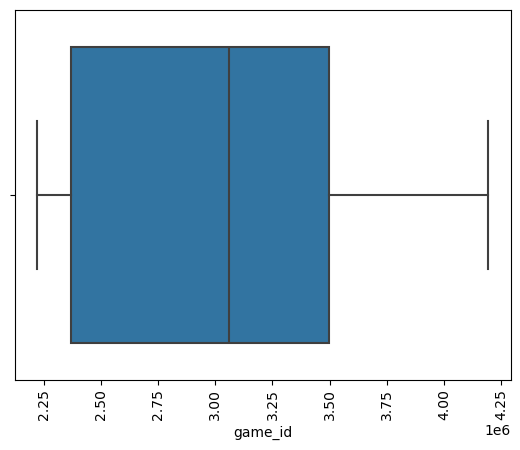

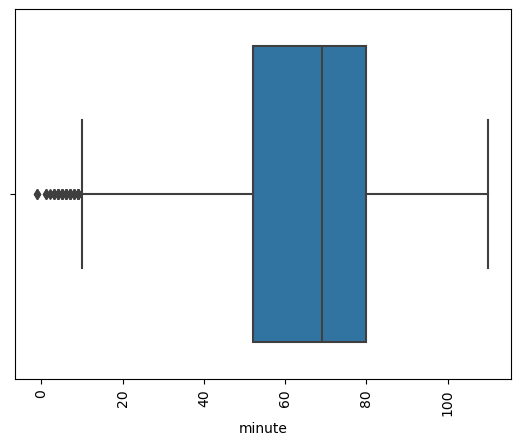

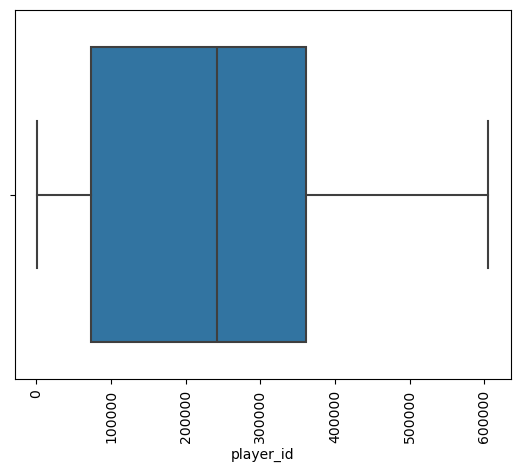

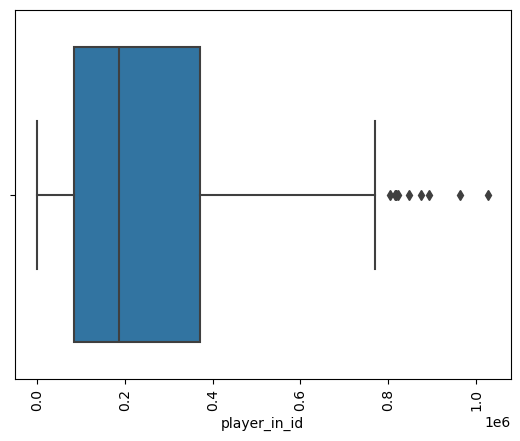

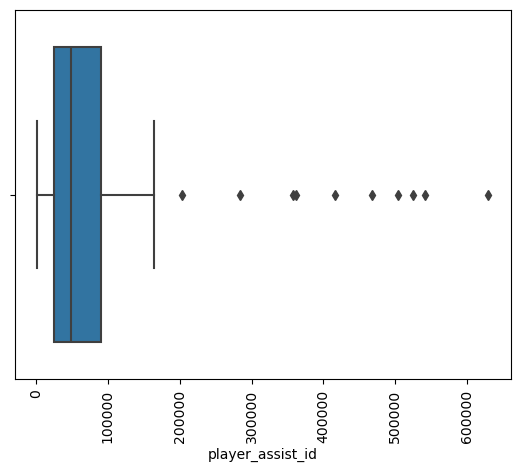

In [20]:
for d in conti_game_events.columns:
    sns.boxplot(x=conti_game_events[d])
    plt.xticks(rotation=90)
    plt.show()

We cannot perform outlier treatment on this dataset.
1. Minute: Cannot perform outlier because any player can get injured or get substitutes in the early stages of the match.
2. Player_in_id and player_assist_id are unique identifiers so they cannot be treated.


In [21]:
game_lineups = pd.read_excel("C:\\Users\\DIVYAM\\OneDrive\\Desktop\\c10project1\\game_lineups.xlsx")
game_lineups.head(1)

,game_lineups_id,game_id,type,number,player_id,player_name,team_captain,position
0,f2570d1504fc02f4b6c7608e8dcf89a3,4087925,substitutes,34,242284,Ethan Horvath,0,Goalkeeper


In [22]:
game_lineups.shape

(219, 8)

In [23]:
game_lineups.describe()

,game_id,number,player_id,team_captain
count,2.190000e+02,219.000000,219.000000,219.000000
mean,4.119483e+06,17.899543,344990.013699,0.041096
std,3.363349e+04,12.263878,144217.605907,0.198967
min,4.087925e+06,2.000000,49723.000000,0.000000
25%,4.095178e+06,11.000000,277884.500000,0.000000
50%,4.103508e+06,16.000000,341049.000000,0.000000
75%,4.150495e+06,22.000000,504215.000000,0.000000
max,4.220942e+06,99.000000,578539.000000,1.000000


In [24]:
game_lineups.isnull().sum()

game_lineups_id    0
game_id            0
type               0
number             0
player_id          0
player_name        0
team_captain       0
position           0
dtype: int64

In [25]:
conti_game_lineups = game_lineups.select_dtypes(include = "number")
conti_game_lineups

,game_id,number,player_id,team_captain
0,4087925,34,242284,0
1,4087928,13,145466,0
2,4087929,26,578539,0
3,4087935,26,578539,0
4,4087936,13,145466,1
...,...,...,...,...
214,4194152,7,504215,0
215,4194152,23,124732,0
216,4194154,13,103064,0
217,4204000,14,315762,0


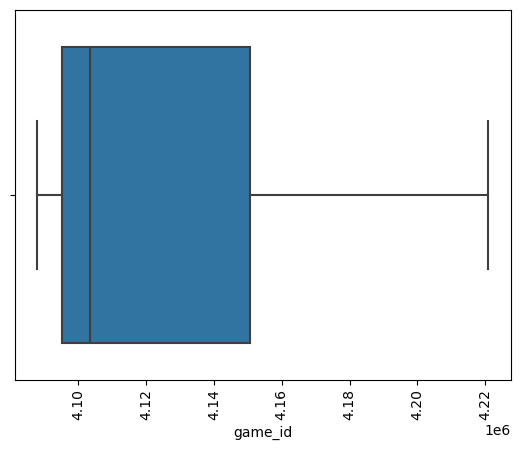

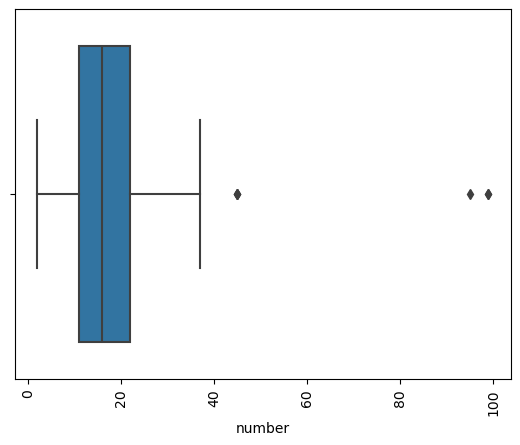

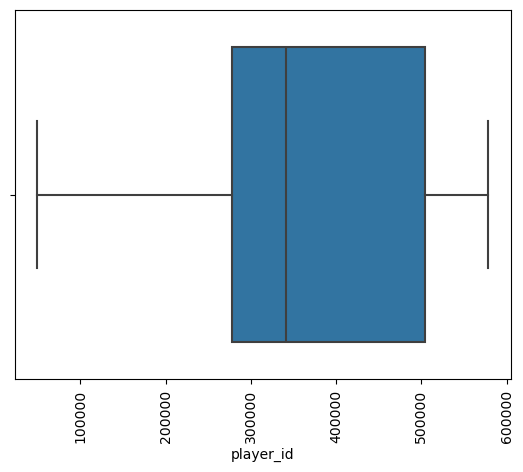

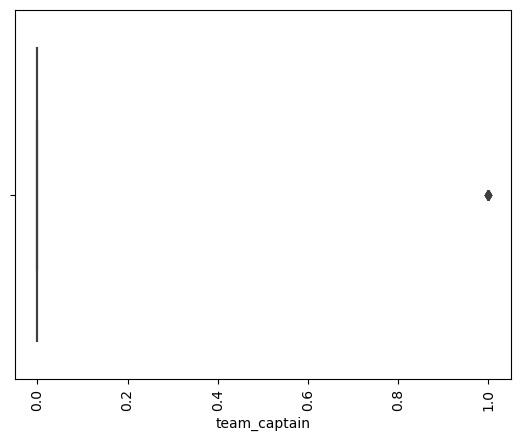

In [26]:
for e in conti_game_lineups.columns:
    sns.boxplot(x=conti_game_lineups[e])
    plt.xticks(rotation=90)
    plt.show()

We cannot do outlier treatment on team_captain and number because jersey number is a number given to every player so we cannot change their 
number and team_captain can also not be changed a team will have a single captain then its not as issue of a outlier.


In [27]:
games = pd.read_excel("C:\\Users\\DIVYAM\\OneDrive\\Desktop\\c10project1\\games.xlsx")
games.head(1)

,game_id,competition_id,season,round,date,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
0,2222734,RU1,2012,19. Matchday,2012-12-07,2,3,11.0,10.0,Miodrag Bozovic,Slavoljub Muslin,Olimp-2,5700.0,Sergey Kuznetsov,NaN,NaN,FK Rostov,FK Krasnodar,02:03:00,domestic_league


In [28]:
games.shape

(3268, 20)

In [29]:
games.describe()

,game_id,season,date,home_club_goals,away_club_goals,home_club_position,away_club_position,attendance,home_club_formation,away_club_formation
count,3.268000e+03,3268.000000,3268,3268.000000,3268.000000,2789.000000,2789.000000,3153.000000,0.0,0.0
mean,2.693024e+06,2015.455630,2016-06-03 15:27:32.386780928,1.631273,1.307834,9.184654,9.506633,29384.731050,NaN,NaN
min,2.219794e+06,2012.000000,2012-07-13 00:00:00,0.000000,0.000000,1.000000,1.000000,300.000000,NaN,NaN
25%,2.332252e+06,2013.000000,2014-02-01 00:00:00,1.000000,0.000000,5.000000,5.000000,14081.000000,NaN,NaN
50%,2.697547e+06,2016.000000,2016-08-06 00:00:00,1.000000,1.000000,9.000000,9.000000,26788.000000,NaN,NaN
75%,3.050395e+06,2018.000000,2018-09-15 06:00:00,2.000000,2.000000,13.000000,14.000000,42558.000000,NaN,NaN
max,3.451629e+06,2020.000000,2020-09-27 00:00:00,9.000000,9.000000,20.000000,21.000000,81365.000000,NaN,NaN
std,3.495558e+05,2.442392,NaN,1.394673,1.277327,5.230755,5.318315,19437.673126,NaN,NaN


In [30]:
games.isnull().sum()

game_id                      0
competition_id               0
season                       0
round                        0
date                         0
home_club_goals              0
away_club_goals              0
home_club_position         479
away_club_position         479
home_club_manager_name       5
away_club_manager_name       5
stadium                      0
attendance                 115
referee                      2
home_club_formation       3268
away_club_formation       3268
home_club_name             110
away_club_name              63
aggregate                    0
competition_type             0
dtype: int64

In [31]:
games.drop(["home_club_formation","away_club_formation"],axis=1,inplace=True)
#Dropping these two columns because there are no values in these columns

In [32]:
conti_games = games.select_dtypes(include = "number")
categ_games = games.select_dtypes(exclude = "number")

In [33]:
conti_games.isnull().sum()

game_id                 0
season                  0
home_club_goals         0
away_club_goals         0
home_club_position    479
away_club_position    479
attendance            115
dtype: int64

In [34]:
games['home_club_position'] = games['home_club_position'].fillna(games['home_club_position'].median())
games['away_club_position'] = games['away_club_position'].fillna(games['away_club_position'].median())
games['attendance'] = games['attendance'].fillna(games['attendance'].median())

In [35]:
categ_games.isnull().sum()

competition_id              0
round                       0
date                        0
home_club_manager_name      5
away_club_manager_name      5
stadium                     0
referee                     2
home_club_name            110
away_club_name             63
aggregate                   0
competition_type            0
dtype: int64

In [36]:
games['home_club_name'] = games['home_club_name'].fillna("Not Available")
games['home_club_manager_name'] = games['home_club_manager_name'].fillna("Not Available")
games['away_club_manager_name'] = games['away_club_manager_name'].fillna("Not Available")
games['referee'] = games['referee'].fillna("Not Available")
games['away_club_name'] = games['away_club_name'].fillna("Not Available")

In [37]:
games.isnull().sum()

game_id                   0
competition_id            0
season                    0
round                     0
date                      0
home_club_goals           0
away_club_goals           0
home_club_position        0
away_club_position        0
home_club_manager_name    0
away_club_manager_name    0
stadium                   0
attendance                0
referee                   0
home_club_name            0
away_club_name            0
aggregate                 0
competition_type          0
dtype: int64

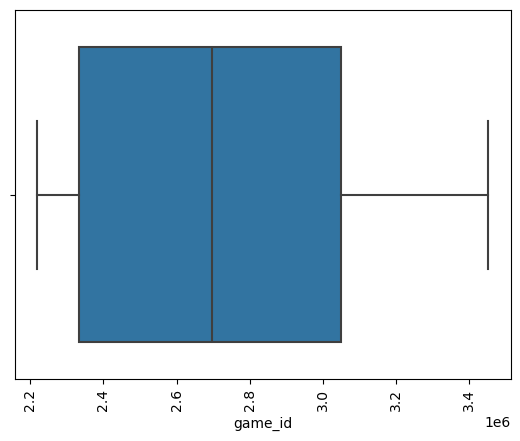

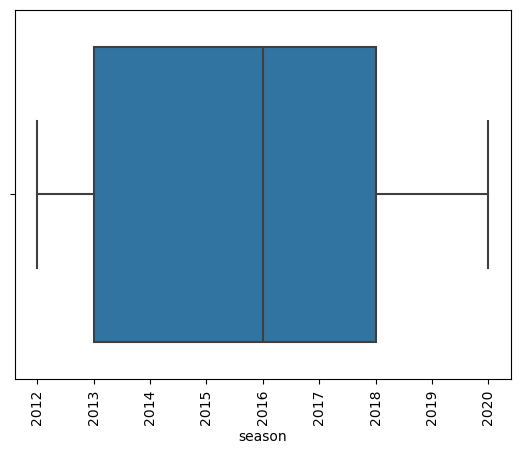

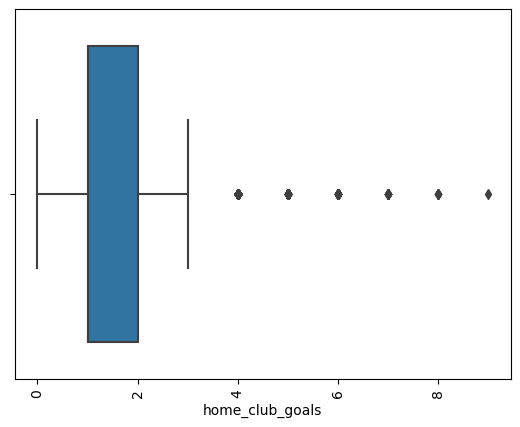

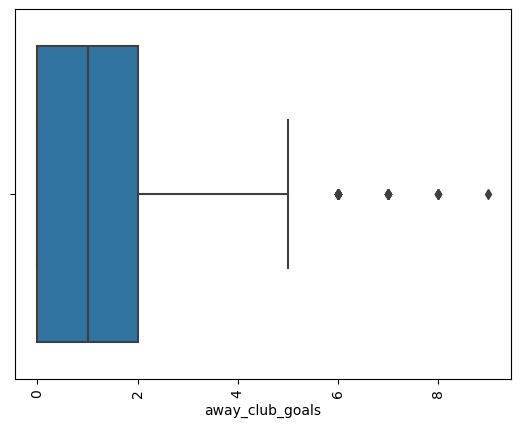

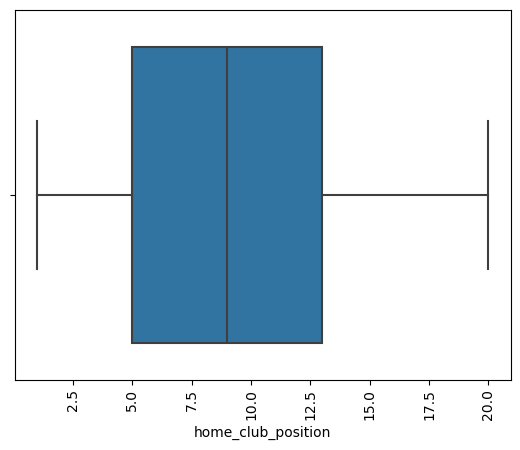

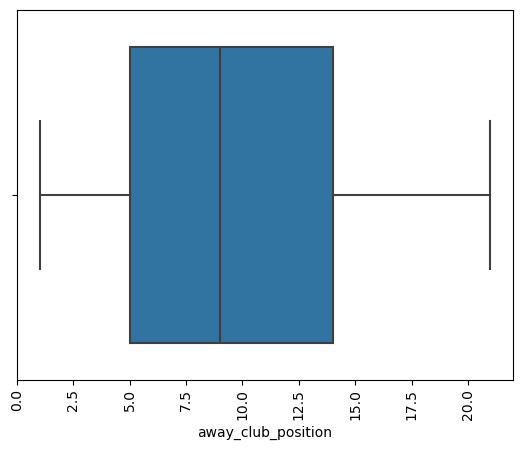

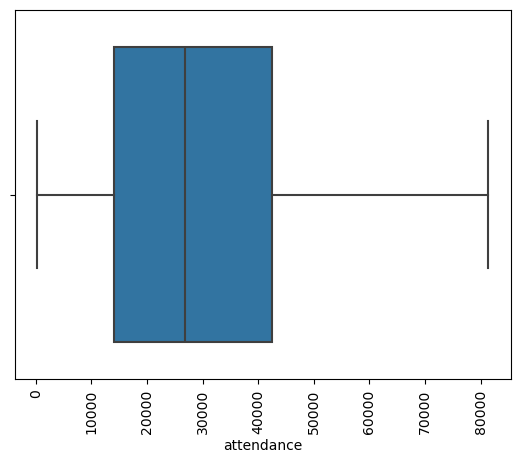

In [38]:
for g in conti_games.columns:
    sns.boxplot(x=conti_games[g])
    plt.xticks(rotation=90)
    plt.show()

we cannot perform outlier treatment on home_club_goals and away_club_goals because its no. of goals they have scored against some matches and we cannot change that no. of goals.

In [39]:
players = pd.read_excel("C:\\Users\\DIVYAM\\OneDrive\\Desktop\\c10project1\\players.xlsx")
players.head(1)

,player_id,name,last_season,current_club_id,player_code,country_of_birth,date_of_birth,sub_position,position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,contract_expiration_date,agent_name
0,124732,John Anthony Brooks,2023,533,john-anthony-brooks,Germany,1993-01-28,Centre-Back,Defender,left,194.0,2000000.0,15000000.0,2024-06-30,ROGON


In [40]:
players.shape

(152, 15)

In [41]:
players.describe()

,player_id,last_season,current_club_id,date_of_birth,height_in_cm,market_value_in_eur,highest_market_value_in_eur,contract_expiration_date
count,1.520000e+02,152.000000,152.000000,152,149.000000,1.140000e+02,1.480000e+02,106
mean,3.523756e+05,2019.539474,1407.756579,1995-07-30 13:25:15.789473664,182.765101,3.694298e+06,4.886993e+06,2025-07-02 22:11:19.245283072
min,1.321000e+03,2012.000000,3.000000,1971-05-18 00:00:00,162.000000,7.500000e+04,5.000000e+04,2023-05-31 00:00:00
25%,1.311800e+05,2017.000000,165.750000,1991-02-15 12:00:00,177.000000,4.000000e+05,6.375000e+05,2024-06-30 00:00:00
50%,3.506020e+05,2021.000000,604.000000,1997-03-03 00:00:00,183.000000,1.000000e+06,2.000000e+06,2025-06-30 00:00:00
75%,5.061150e+05,2023.000000,1113.250000,2000-10-25 00:00:00,188.000000,3.875000e+06,5.000000e+06,2026-06-30 00:00:00
max,1.163778e+06,2023.000000,23826.000000,2004-06-30 00:00:00,204.000000,3.000000e+07,6.000000e+07,2028-06-30 00:00:00
std,2.408696e+05,3.578600,2889.523900,NaN,7.152196,6.134413e+06,8.087340e+06,NaN


In [42]:
conti_players = players.select_dtypes(include = "number")
conti_players
categ_players = players.select_dtypes(exclude = "number")
categ_players

,name,player_code,country_of_birth,date_of_birth,sub_position,position,foot,contract_expiration_date,agent_name
0,John Anthony Brooks,john-anthony-brooks,Germany,1993-01-28,Centre-Back,Defender,left,2024-06-30,ROGON
1,Emerson Hyndman,emerson-hyndman,United States,1996-04-09,Central Midfield,Midfield,right,NaT,OmniSports
2,Lynden Gooch,lynden-gooch,United States,1995-12-24,Right Winger,Attack,right,2024-06-30,Unique Sports Group
3,Timothy Weah,timothy-weah,United States,2000-02-22,Right Midfield,Midfield,right,2028-06-30,BS Group - BS Law
4,Djordje Mihailovic,djordje-mihailovic,United States,1998-11-10,Attacking Midfield,Midfield,NaN,2026-06-30,YMU Management Ltd.
...,...,...,...,...,...,...,...,...,...
147,Desevio Payne,desevio-payne,United States,1995-11-30,Right-Back,Defender,right,NaT,NaN
148,Alejandro Bedoya,alejandro-bedoya,United States,1987-04-29,Central Midfield,Midfield,right,2023-12-31,YMU Group
149,Joe Gyau,joe-gyau,United States,1992-09-16,Left Winger,Attack,both,2023-12-31,BR Group Management
150,Brad Friedel,brad-friedel,United States,1971-05-18,Goalkeeper,Goalkeeper,NaN,NaT,NaN


In [43]:
conti_players.isnull().sum()

player_id                       0
last_season                     0
current_club_id                 0
height_in_cm                    3
market_value_in_eur            38
highest_market_value_in_eur     4
dtype: int64

In [44]:
players['height_in_cm'] = players['height_in_cm'].fillna(players['height_in_cm'].median())
players['market_value_in_eur'] = players['market_value_in_eur'].fillna(players['market_value_in_eur'].median())
players['highest_market_value_in_eur'] = players['highest_market_value_in_eur'].fillna(players['highest_market_value_in_eur'].median())

In [45]:
categ_players.isnull().sum()

name                         0
player_code                  0
country_of_birth             0
date_of_birth                0
sub_position                 0
position                     0
foot                        11
contract_expiration_date    46
agent_name                  45
dtype: int64

In [46]:
players['foot'] = players['foot'].fillna("Not Available")
players['contract_expiration_date'] = players['contract_expiration_date'].fillna("Not Available")
players['agent_name'] = players['agent_name'].fillna("Not Available")

In [47]:
players.isnull().sum()

player_id                      0
name                           0
last_season                    0
current_club_id                0
player_code                    0
country_of_birth               0
date_of_birth                  0
sub_position                   0
position                       0
foot                           0
height_in_cm                   0
market_value_in_eur            0
highest_market_value_in_eur    0
contract_expiration_date       0
agent_name                     0
dtype: int64

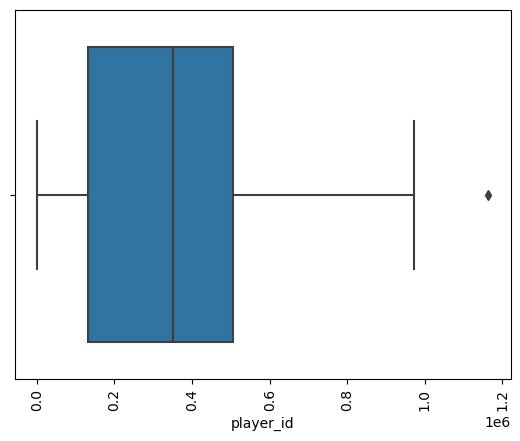

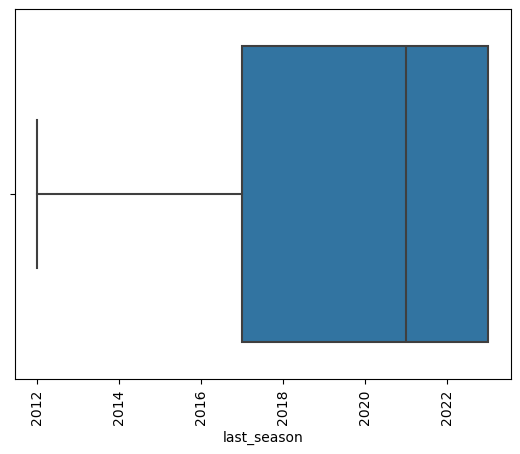

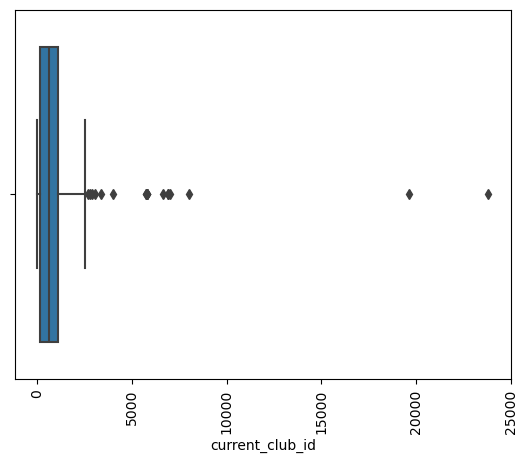

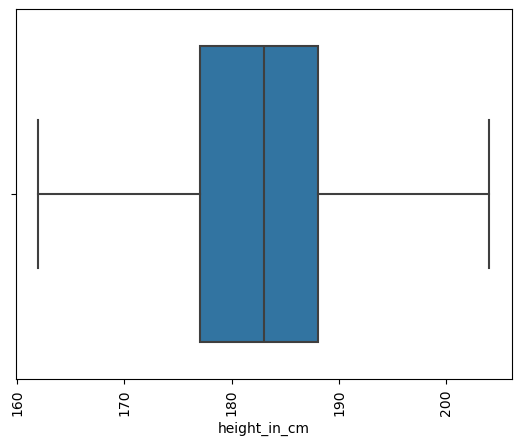

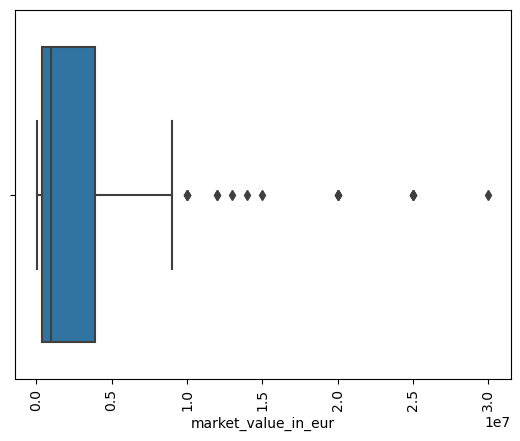

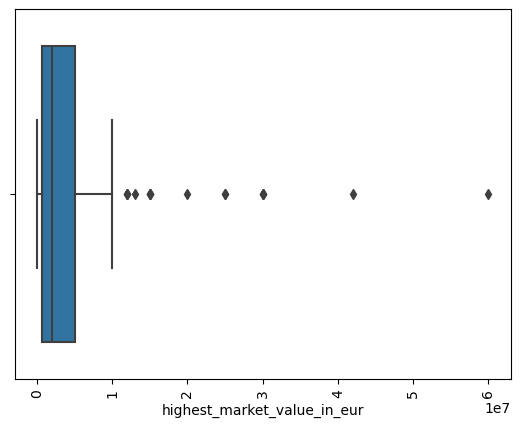

In [48]:
for i in conti_players.columns:
    sns.boxplot(x=conti_players[i])
    plt.xticks(rotation=90)
    plt.show()

we cannot perform outlier treatment 
1.player_id bacause it is a unique identifier of a player.
2.Current_club_id again a unique identifier cannot perform outlier treatment.
3.Heigth can't be changed.
4.Market_value_in_eur and highest_market_value_in_eur cannot be treated as this amount is given to players on the basis of their skill so we reduce or increase their pay that can affect their market value.

In [49]:
a= games.merge(appeareances, on='game_id', how='outer')
a.head(1)

,game_id,competition_id_x,season,round,date_x,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,...,appearance_id,player_id,date_y,player_name,competition_id_y,yellow_cards,red_cards,goals,assists,minutes_played
0,2222734,RU1,2012,19. Matchday,2012-12-07,2,3,11.0,10.0,Miodrag Bozovic,...,2222734_104203,104203,2012-12-07,Eugene Starikov,RU1,0,0,0,0,38


In [50]:
b = a.merge(game_events, on='game_id', how='outer')
b.head(1)

,game_id,competition_id_x,season,round,date_x,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,...,assists,minutes_played,game_event_id,date,minute,type,player_id_y,description,player_in_id,player_assist_id
0,2222734,RU1,2012.0,19. Matchday,2012-12-07,2.0,3.0,11.0,10.0,Miodrag Bozovic,...,0.0,38.0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
c = b.merge(game_lineups, on='game_id', how='outer')
c.head(1)

,game_id,competition_id_x,season,round,date_x,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,...,description,player_in_id,player_assist_id,game_lineups_id,type_y,number,player_id,player_name_y,team_captain,position
0,2222734,RU1,2012.0,19. Matchday,2012-12-07,2.0,3.0,11.0,10.0,Miodrag Bozovic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
d = c.merge(players, on='player_id', how='outer')
d.head(1)

,game_id,competition_id_x,season,round,date_x,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,...,country_of_birth,date_of_birth,sub_position,position_y,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,contract_expiration_date,agent_name
0,2222734.0,RU1,2012.0,19. Matchday,2012-12-07,2.0,3.0,11.0,10.0,Miodrag Bozovic,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
d.shape

(4811, 57)

In [54]:
data = d.copy()

In [55]:
data.head()

,game_id,competition_id_x,season,round,date_x,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,...,country_of_birth,date_of_birth,sub_position,position_y,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,contract_expiration_date,agent_name
0,2222734.0,RU1,2012.0,19. Matchday,2012-12-07,2.0,3.0,11.0,10.0,Miodrag Bozovic,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2224572.0,DK1,2012.0,3. Matchday,2012-07-28,1.0,2.0,12.0,1.0,Jess Thorup,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2224628.0,DK1,2012.0,22. Matchday,2013-03-08,2.0,0.0,3.0,10.0,Colin Todd,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2224655.0,DK1,2012.0,22. Matchday,2013-03-10,0.0,3.0,6.0,12.0,Peter Rensen,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2224729.0,DK1,2012.0,1. Matchday,2012-07-15,0.0,1.0,9.0,5.0,Auri Skarbalius,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
data.shape

(4811, 57)

In [57]:
data.dtypes

game_id                               float64
competition_id_x                       object
season                                float64
round                                  object
date_x                         datetime64[ns]
home_club_goals                       float64
away_club_goals                       float64
home_club_position                    float64
away_club_position                    float64
home_club_manager_name                 object
away_club_manager_name                 object
stadium                                object
attendance                            float64
referee                                object
home_club_name                         object
away_club_name                         object
aggregate                              object
competition_type                       object
appearance_id                          object
player_id_x                           float64
date_y                         datetime64[ns]
player_name_x                     

In [58]:
data['team_captain'] = data['team_captain'].astype(bool)

In [59]:
data.isnull().sum()

game_id                         125
competition_id_x               1002
season                         1002
round                          1002
date_x                         1002
home_club_goals                1002
away_club_goals                1002
home_club_position             1002
away_club_position             1002
home_club_manager_name         1002
away_club_manager_name         1002
stadium                        1002
attendance                     1002
referee                        1002
home_club_name                 1002
away_club_name                 1002
aggregate                      1002
competition_type               1002
appearance_id                  1002
player_id_x                    1002
date_y                         1002
player_name_x                  1002
competition_id_y               1002
yellow_cards                   1002
red_cards                      1002
goals                          1002
assists                        1002
minutes_played              

In [60]:
data.drop(['date_x','player_id_x','player_assist_id','date_y','description','player_id_y','competition_id_y','player_name_y'],axis=1,inplace=True)

In [61]:
conti_data = data.select_dtypes(include = 'number')
categ_data = data.select_dtypes(exclude = 'number')

In [62]:
conti_data.isnull().sum()

game_id                         125
season                         1002
home_club_goals                1002
away_club_goals                1002
home_club_position             1002
away_club_position             1002
attendance                     1002
yellow_cards                   1002
red_cards                      1002
goals                          1002
assists                        1002
minutes_played                 1002
minute                         2727
player_in_id                   2727
number                         4567
player_id                      4442
last_season                    4442
current_club_id                4442
height_in_cm                   4442
market_value_in_eur            4442
highest_market_value_in_eur    4442
dtype: int64

In [63]:
for BB in conti_data.columns:
    data[BB] = conti_data[BB].fillna(conti_data[BB].median())

In [64]:
for CC in categ_data.columns:
    data[CC] = categ_data[CC].fillna("Not Available")

In [65]:
data.isnull().sum()

game_id                        0
competition_id_x               0
season                         0
round                          0
home_club_goals                0
away_club_goals                0
home_club_position             0
away_club_position             0
home_club_manager_name         0
away_club_manager_name         0
stadium                        0
attendance                     0
referee                        0
home_club_name                 0
away_club_name                 0
aggregate                      0
competition_type               0
appearance_id                  0
player_name_x                  0
yellow_cards                   0
red_cards                      0
goals                          0
assists                        0
minutes_played                 0
game_event_id                  0
date                           0
minute                         0
type_x                         0
player_in_id                   0
game_lineups_id                0
type_y    

In [66]:
# data.to_csv("Football_data_merged_cleaned(new).csv")

In [67]:
df = data.copy()

In [68]:
df.columns

Index(['game_id', 'competition_id_x', 'season', 'round', 'home_club_goals',
       'away_club_goals', 'home_club_position', 'away_club_position',
       'home_club_manager_name', 'away_club_manager_name', 'stadium',
       'attendance', 'referee', 'home_club_name', 'away_club_name',
       'aggregate', 'competition_type', 'appearance_id', 'player_name_x',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'game_event_id', 'date', 'minute', 'type_x', 'player_in_id',
       'game_lineups_id', 'type_y', 'number', 'player_id', 'team_captain',
       'position_x', 'name', 'last_season', 'current_club_id', 'player_code',
       'country_of_birth', 'date_of_birth', 'sub_position', 'position_y',
       'foot', 'height_in_cm', 'market_value_in_eur',
       'highest_market_value_in_eur', 'contract_expiration_date',
       'agent_name'],
      dtype='object')

# Areas of Interest
1. Performance Analysis
2. Player Profile and Market Value
3. Team Comparison
4. Attendance and Stadium Analysis
5. Referee Analysis
6. Substitution Patterns
7. Event Analysis
8. Competition Analysis
9. Player Attributes and Demographics
10. Contract Management


Here are the business obejective questions

Performance Analysis:
   Identify and monitor Key Performance Indicators (KPIs) that directly contribute to team success.
   Which teams had the highest goals scored(Top 10).
   Which games had the highest attendance and what teams were playing that match?

Player Profile and Market Value
   What is the probability that a player has a market value above €2 million given that the player is from Germany? 
   What is the probability that a player is from United States and has a market value above €3 million?

Team Comparison
  What is the distribution of goals scored by the top 5 teams across all matches?
  How does the total market value of a team correlate with its league position or points accumulated at the end?

Attendance and Stadium analysis
  Which stadiums have the highest and lowest average attendance?
  Is there a relationship between the average attendance at home games and the number of goals scored by the home team?

Refree analysis
  Which referees have officiated the most matches?
  How do referees differ in terms of the average number of yellow and red cards issued? 

Substitution patterns 
 
  Optimize substitution strategies by analyzing the impact of substitutions on game outcomes, such as goals scored or conceded.
  Do certain players get substituted more frequently?

Event Analysis
  
  Analyze critical match events (e.g., goals, fouls, corners) to gain insights into their impact on overall team performances.
  Improve match preparation by identifying trends in key events, such as set-piece effectiveness, and adjusting tactics accordingly.

competition analysis
  How many matches were played in each competition?
  How does the goal-scoring rate vary across different competitions?


Player attributes and demographics
   How does market value vary with player position (e.g., defender, midfielder, forward)?
   What is the distribution of player nationalities in the dataset?


contract management 
   How many players have contracts expiring each year?
   Manage contract renewals and extensions strategically, focusing on retaining top talent and avoiding overpaying for decli

Overall Mean: 1.5260860527956766
Sample Size: 30 Sample Mean: 1.5335
Sample Size: 50 Sample Mean: 1.52824
Sample Size: 100 Sample Mean: 1.52366


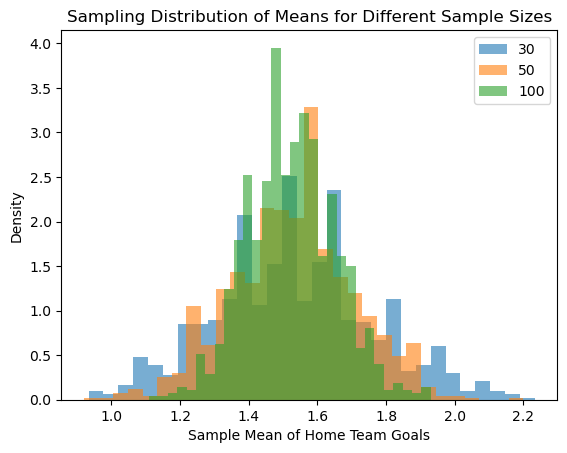

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def central_limit_theorem_sampling(df, sample_sizes=[30, 50, 100], num_samples=1000):
    overall_mean = df['home_club_goals'].mean() 
    print("Overall Mean:", overall_mean)
    
    for sample_size in sample_sizes:
        sample_means = []
        for _ in range(num_samples):
            sample = df.sample(n=sample_size)
            sample_mean = sample['home_club_goals'].mean()
            sample_means.append(sample_mean)
        
        plt.hist(sample_means, bins=30, density=True, alpha=0.6, label=sample_size)
    
        print("Sample Size:",sample_size, "Sample Mean:" ,np.mean(sample_means))

    plt.title('Sampling Distribution of Means for Different Sample Sizes')
    plt.xlabel('Sample Mean of Home Team Goals')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

central_limit_theorem_sampling(df, sample_sizes=[30, 50, 100])

In [70]:
#1 What is the probability that a player with a market value above 200,000 is from Germany?
Germany_players = df[df['country_of_birth'] == 'Germany']

In [71]:
prob_market_value_given_Germany = (Germany_players['market_value_in_eur'] > 200000).mean()

In [72]:
print("Probability that a player has a market value above 200K given they are from Germany:", prob_market_value_given_Germany)

Probability that a player has a market value above 200K given they are from Germany: 0.9090909090909091


In [73]:
# There is a 90% chance that a player has a market value above 2M and the origin of that player is germany.

In [74]:
#2 What is the probability that a player from the United States has a market value above 300,000?
UnitedStates_and_high_value = (df['country_of_birth'] == 'United States') & (df['market_value_in_eur'] > 100000)

In [75]:
prob_UnitedStates_and_value = UnitedStates_and_high_value.mean()

In [76]:
print("Probability that a player is from United States and has a market value above 100K:", prob_UnitedStates_and_value)

Probability that a player is from United States and has a market value above 100K: 0.057160673456661815


In [77]:
# There is 5% chance that a player is from United States and is getting a contract of more than 100K.

In [78]:
# log reg
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score 

In [79]:
df_conti = df.select_dtypes(include = 'number')
df_categ = df.select_dtypes(exclude = 'number')

In [80]:
scaler = StandardScaler()
for DD in df_conti.columns:
    df[DD]= scaler.fit_transform(df[DD].to_numpy().reshape(-1,1))

In [81]:
for EE in df_categ.columns:   # very imp
    print(EE,"contains \n:",df_categ[EE].value_counts())               

competition_id_x contains 
: competition_id_x
L1               1143
Not Available    1002
GB1               773
DK1               428
NL1               298
BE1               242
FR1               166
EL                118
DFB               110
CL                104
SC1               103
FAC                54
IT1                43
NLP                41
DKP                34
ELQ                31
TR1                25
CLQ                15
UKR1               11
POCP               10
SFA                10
RU1                10
PO1                 9
ES1                 8
CDR                 8
CIT                 5
BESC                3
NLSC                2
DFL                 2
UKRP                1
FRCH                1
USC                 1
Name: count, dtype: int64
round contains 
: round
Not Available          1002
2. Matchday             112
7. Matchday             110
1. Matchday             108
18. Matchday            108
                       ... 
5th round deciders        1
Grou

# Q. Can we predict whether a player is the team captain based on their playing position, number of minutes played, and market value?

In [82]:
categ1= ['position_x','type_y']

enc = preprocessing.LabelEncoder()

for k in categ1:
    df[k]= enc.fit_transform(df[k])

In [83]:
y = df[['team_captain']]
x = df[['position_x', 'minutes_played', 'market_value_in_eur']]

In [84]:
y

,team_captain
0,True
1,True
2,True
3,True
4,True
...,...
4806,True
4807,True
4808,True
4809,True


In [85]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7 ,random_state=42)

In [86]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3367, 3)
(3367, 1)
(1444, 3)
(1444, 1)


In [87]:
log_reg = LogisticRegression()

In [88]:
log_reg_model = log_reg.fit(x_train, y_train)

In [89]:
log_reg.score(x_train, y_train)

0.9848529848529849

In [90]:
y_pred = log_reg.predict(x_test)

In [91]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[  55   20]
 [   6 1363]]


In [92]:
from sklearn.metrics import f1_score
print(f1_score(y_test, y_pred, average="weighted"))

0.9811135030656597


In [93]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.981994459833795


In [94]:
from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test, log_reg.predict_proba(x_test)[:,1])
print("roc scroe is", roc)

roc scroe is 0.8907815924032141


In [95]:
from sklearn.metrics import recall_score
print("recall", recall_score(y_test, y_pred, average="weighted"))

recall 0.981994459833795


In [96]:
from sklearn.metrics import precision_score
print("precision", precision_score(y_test, y_pred, average="weighted"))

precision 0.9811810313319865


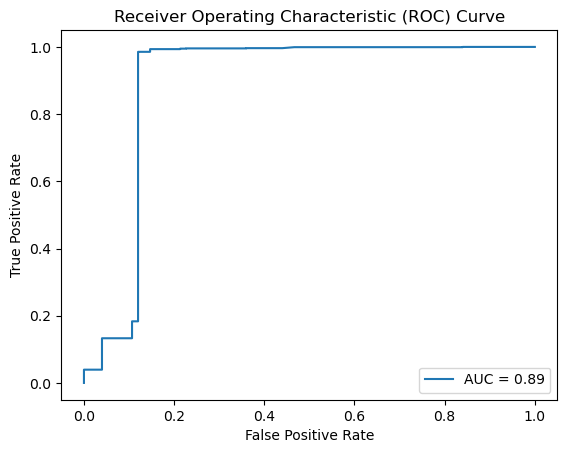

In [97]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


y_prob = log_reg.predict_proba(x_test)[:, 1]


fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Interpretation: 
The logistic regression model appears to be a valuable tool for predicting team captains based on the given features.
It can provide valuable insights for teams in areas such as player selection, contract negotiations, and team building. 

In [98]:
###KNN 

# Q. Can we predict the type of event (e.g., goal, substitution) that occurs during a game based on match dynamics such as minute, player performance, and team?

In [99]:
x_k = df[['minute', 'goals', 'assists', 'yellow_cards', 'red_cards', 'home_club_goals']]
y_k = df[['type_x']]

In [100]:
y_k

,type_x
0,Not Available
1,Not Available
2,Not Available
3,Not Available
4,Not Available
...,...
4806,Not Available
4807,Not Available
4808,Not Available
4809,Not Available


In [101]:
indep_train, indep_test, dep_train, dep_test = train_test_split(x_k, y_k, test_size=0.2, random_state=42)

In [102]:
print(indep_train.shape)  
print(dep_train.shape)    
print(indep_test.shape)  
print(dep_test.shape)     

(3848, 6)
(3848, 1)
(963, 6)
(963, 1)


In [103]:
print(len(indep_train))
my_k = int(round(len(indep_train)**0.5,0))
my_k

3848


62

In [104]:
from sklearn import neighbors

In [105]:
performance = []
k_options = np.arange(62,3847,62)

for which_k in k_options:
    temp_model = neighbors.KNeighborsClassifier(which_k)
    temp_model.fit(indep_train,dep_train)
    y_pred = temp_model.predict(indep_test)
    print("if k is", which_k, "performance is", accuracy_score(dep_test,y_pred)*100)
    performance.append(accuracy_score(dep_test,y_pred)*100)

if k is 62 performance is 84.2159916926272
if k is 124 performance is 81.30841121495327
if k is 186 performance is 78.29698857736241
if k is 248 performance is 77.36240913811008
if k is 310 performance is 74.35098650051921
if k is 372 performance is 72.48182762201453
if k is 434 performance is 71.23572170301142
if k is 496 performance is 71.33956386292834
if k is 558 performance is 69.5742471443406
if k is 620 performance is 68.43198338525441
if k is 682 performance is 66.66666666666666
if k is 744 performance is 64.07061266874351
if k is 806 performance is 63.75908618899273
if k is 868 performance is 62.824506749740394
if k is 930 performance is 58.77466251298027
if k is 992 performance is 58.04776739356179
if k is 1054 performance is 57.3208722741433
if k is 1116 performance is 57.217030114226375
if k is 1178 performance is 57.009345794392516
if k is 1240 performance is 56.90550363447559
if k is 1302 performance is 56.80166147455867
if k is 1364 performance is 56.69781931464174
if k 

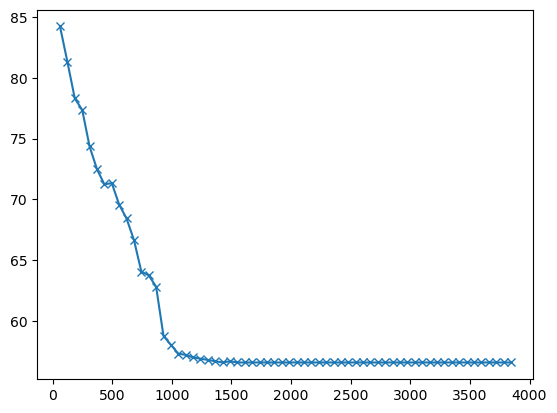

In [106]:
plt.plot(k_options,performance,marker='x');

In [107]:
final_model = neighbors.KNeighborsClassifier(62)
final_model.fit(indep_train,dep_train)
y_pred_k = final_model.predict(indep_test)
print("if k is 62 performance is", accuracy_score(dep_test,y_pred_k)*100)

if k is 62 performance is 84.2159916926272


Analysis:
Based on the analysis, it appears that the KNN model can effectively predict the type of event during a game based on the given match dynamics. The model's performance is promising, with an accuracy of 84.21%. 

In [108]:
## lin reg 

In [109]:
from sklearn.preprocessing import LabelEncoder # import module from package
from sklearn import preprocessing

Q. How does the position a player plays in (e.g., midfielder, defender) affect their market value?

In [110]:
enc = LabelEncoder()
df['team_captain'] = enc.fit_transform(df['team_captain'])
df['position_y'] = enc.fit_transform(df['position_y'])

In [111]:
# df['market_value_in_eur'] = scaler.fit_transform(df['market_value_in_eur'].to_numpy().reshape(-1,1))

In [112]:
x_l = df[['position_y']]
y_l = df[['market_value_in_eur']]

In [113]:
y_l

,market_value_in_eur
0,-0.134795
1,-0.134795
2,-0.134795
3,-0.134795
4,-0.134795
...,...
4806,0.736283
4807,-0.055606
4808,-0.728711
4809,-0.689117


In [114]:
xl_train, xl_test, yl_train, yl_test = train_test_split(x_l,y_l, train_size= 0.7, random_state = 42)

In [115]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [116]:
lin_reg_model = lin_reg.fit(xl_train, yl_train)

In [117]:
print(lin_reg_model.score(xl_train, yl_train))

0.13966098983894482


In [118]:
y_predl = lin_reg_model.predict((xl_test.to_numpy().reshape(-1,1)))

In [119]:
print(lin_reg_model.score(yl_test.to_numpy().reshape(-1,1), y_predl))

-26.84882127811212


In [120]:
mse1 = mean_squared_error(yl_test,y_predl)
print("MSE",mse1)
mse1 = mean_squared_error(y_predl, yl_test, squared=False)
print("RMSE=",mse1)

print("MAE =",  mean_absolute_error(yl_test,y_predl))

r_squared1 = r2_score(yl_test, y_predl)
print("R2 =", r_squared1) #check reliability of the model

MSE 0.7786017902549952
RMSE= 0.8823841511807627
MAE = 0.2258290764570782
R2 = 0.15537648207287824


In [121]:
 #df['attendance'] = scaler.fit_transform(df['attendance'].to_numpy().reshape(-1,1))

In [122]:
enc = LabelEncoder()
df['position_x'] = enc.fit_transform(df['position_x'])

In [123]:
x_l2 = df[['attendance']]
y_l2 = df[['yellow_cards']]

In [124]:
xl2_train, xl2_test, yl2_train, yl2_test = train_test_split(x_l2,y_l2, train_size= 0.7, random_state = 42)

In [125]:
lin_reg_model2 = lin_reg.fit(xl2_train, yl2_train)

In [126]:
print(lin_reg_model2.score(xl2_train, yl2_train))

0.0004954622055087787


In [127]:
y_pred2 = lin_reg_model2.predict((xl2_test.to_numpy().reshape(-1,1)))

In [128]:
print(lin_reg_model2.score(yl2_test.to_numpy().reshape(-1,1), y_pred2))

-0.867377776741791


multiple linear regression

# Q. How do both performance (goals) and non-performance factors (attendance, name, shirt number) impact a player's market value?

In [129]:
xx = df[['goals','highest_market_value_in_eur','attendance','number']]     
yy = df[['market_value_in_eur']]

In [130]:
yy

,market_value_in_eur
0,-0.134795
1,-0.134795
2,-0.134795
3,-0.134795
4,-0.134795
...,...
4806,0.736283
4807,-0.055606
4808,-0.728711
4809,-0.689117


In [131]:
dd= df[['goals','highest_market_value_in_eur','attendance','number','market_value_in_eur']]

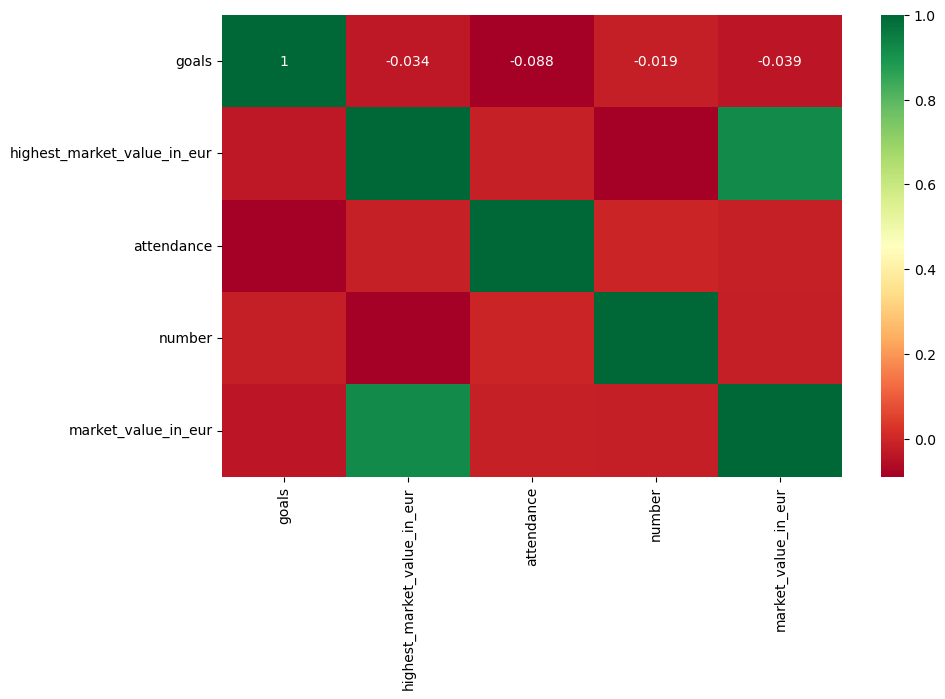

In [132]:
plt.figure(figsize=(10,6))
sns.heatmap(dd.corr(), annot=True, cmap= "RdYlGn")
plt.show()

In [133]:
xx

,goals,highest_market_value_in_eur,attendance,number
0,-0.291544,-0.117835,-1.346095,-0.064346
1,-0.291544,-0.117835,-1.366612,-0.064346
2,-0.291544,-0.117835,-1.474343,-0.064346
3,-0.291544,-0.117835,-1.215073,-0.064346
4,-0.291544,-0.117835,-1.050991,-0.064346
...,...,...,...,...
4806,-0.291544,-0.117835,-0.127306,-0.064346
4807,-0.291544,-0.436740,-0.127306,-0.064346
4808,-0.291544,-0.436740,-0.127306,-0.064346
4809,-0.291544,-0.840688,-0.127306,-0.064346


In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [135]:
def cal_vif(xx):
    vif = pd.Series(name="VIF")
    for i in range(0,xx.shape[1]):
        vif[xx.columns[i]]= variance_inflation_factor(xx.values,i)
    return vif 
vif_values = cal_vif(xx)

In [136]:
print(vif_values)

goals                          1.009561
highest_market_value_in_eur    1.009908
attendance                     1.008203
number                         1.008839
Name: VIF, dtype: float64


In [137]:
xx

,goals,highest_market_value_in_eur,attendance,number
0,-0.291544,-0.117835,-1.346095,-0.064346
1,-0.291544,-0.117835,-1.366612,-0.064346
2,-0.291544,-0.117835,-1.474343,-0.064346
3,-0.291544,-0.117835,-1.215073,-0.064346
4,-0.291544,-0.117835,-1.050991,-0.064346
...,...,...,...,...
4806,-0.291544,-0.117835,-0.127306,-0.064346
4807,-0.291544,-0.436740,-0.127306,-0.064346
4808,-0.291544,-0.436740,-0.127306,-0.064346
4809,-0.291544,-0.840688,-0.127306,-0.064346


In [138]:
xx_train, xx_test, yy_train, yy_test = train_test_split(xx, yy, train_size=0.7, random_state=42)

In [139]:
print(xx_train.shape)
print(yy_train.shape)
print(xx_test.shape)
print(yy_test.shape)

(3367, 4)
(3367, 1)
(1444, 4)
(1444, 1)


In [140]:
lin_reg_model_M = lin_reg.fit(xx_train, yy_train)

In [141]:
print(lin_reg_model_M.score(xx_train, yy_train))

0.8583819244303759


In [142]:
y_pred_M = lin_reg_model_M.predict((xx_test.values))

In [143]:
from sklearn.metrics import mean_squared_error # mse and rmse 
from sklearn.metrics import mean_absolute_error # mae 
from sklearn.metrics import r2_score # r-squared

In [144]:
mse = mean_squared_error(yy_test,y_pred_M)
print("MSE",mse)
mse = mean_squared_error(y_pred_M, yy_test, squared=False)
print("RMSE=",mse)

print("MAE =",  mean_absolute_error(yy_test,y_pred_M))

r_squared = r2_score(yy_test, y_pred_M)
print("R2 =", r_squared) 

MSE 0.15810184068245187
RMSE= 0.39762022167195155
MAE = 0.10412558558689436
R2 = 0.8284918753857065


Analysis: Overall, these scores suggest that the model is doing a pretty good job of predicting player market values based on the factors considered. It can explain a significant portion of the variation in market value and is making reasonably accurate predictions. However, there's always room for improvement, and you might consider adding more factors or trying a different model to see if you can get even better results.

# Q Can we predict the type of competition (e.g., league or cup) based on the stadium where the match was held and the attendance size, while also considering the home and away club performance (positions)

In [145]:
df['stadium'] = enc.fit_transform(df['stadium'])
#df['competition_type'] = enc.fit_transform(df['competition_type'])

In [146]:
xx_k = df[['stadium', 'attendance','home_club_position', 'away_club_position']]
yy_k = df[['competition_type']]

In [147]:
yy_k

,competition_type
0,domestic_league
1,domestic_league
2,domestic_league
3,domestic_league
4,domestic_league
...,...
4806,Not Available
4807,Not Available
4808,Not Available
4809,Not Available


In [148]:
xx_k_train, xx_k_test, yy_k_train, yy_k_test = train_test_split(xx_k, yy_k, test_size=0.2, random_state=42)

In [149]:
print(xx_k_train.shape)  
print(yy_k_train.shape)    
print(xx_k_test.shape)  
print(yy_k_test.shape)  

(3848, 4)
(3848, 1)
(963, 4)
(963, 1)


In [150]:
print(len(xx_k_train))
my_kk = int(round(len(indep_train)**0.5,0))
my_kk

3848


62

In [151]:
performance1 = []
k_options1 = np.arange(62,3847,62)

for which_k1 in k_options1:
    temp_model = neighbors.KNeighborsClassifier(which_k1)
    temp_model.fit(xx_k_train,yy_k_train)
    y_pred3 = temp_model.predict(xx_k_test)
    print("if k is", which_k1, "performance is", accuracy_score(yy_k_test,y_pred3)*100)
    performance1.append(accuracy_score(yy_k_test,y_pred3)*100)

if k is 62 performance is 88.1619937694704
if k is 124 performance is 86.70820353063343
if k is 186 performance is 86.70820353063343
if k is 248 performance is 84.73520249221184
if k is 310 performance is 83.48909657320873
if k is 372 performance is 83.17757009345794
if k is 434 performance is 82.76220145379024
if k is 496 performance is 81.51609553478713
if k is 558 performance is 81.20456905503634
if k is 620 performance is 79.12772585669782
if k is 682 performance is 79.12772585669782
if k is 744 performance is 78.92004153686398
if k is 806 performance is 78.71235721703012
if k is 868 performance is 78.71235721703012
if k is 930 performance is 76.73935617860852
if k is 992 performance is 76.11630321910697
if k is 1054 performance is 75.80477673935619
if k is 1116 performance is 75.59709241952233
if k is 1178 performance is 73.72793354101765
if k is 1240 performance is 72.06645898234683
if k is 1302 performance is 71.5472481827622
if k is 1364 performance is 71.02803738317756
if k is

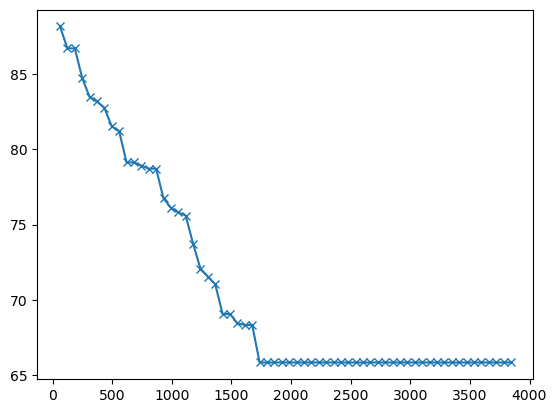

In [152]:
plt.plot(k_options1,performance1,marker='x');

In [153]:
final_model_k = neighbors.KNeighborsClassifier(62)
final_model_k.fit(xx_k_train, yy_k_train)
y_pred_K = final_model_k.predict(xx_k_test)
print("if k is 62 performance is:", accuracy_score(yy_k_test, y_pred_K)*100)

if k is 62 performance is: 88.1619937694704


Analysis: 
1.The KNN classifier is able to predict the type of competition with a reasonable accuracy of 88.16% based on the given features.
2.This model can be used to predict the type of competition for new matches based on the same features.
3.Further improvements to the model could be achieved by exploring other machine learning algorithms or using additional features.

In [154]:
# Kmeans

# Question: Can we group players based on their performance metrics such as goals scored, assists, and minutes played?

In [155]:
#pip install yellowbrick

In [156]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [157]:
X_means= df[['goals', 'assists', 'minutes_played']]

In [158]:
x_blob, y_blob = make_blobs(n_samples=len(X_means), centers=[[4, 5], [0,-1], [2,-3], [1, 2], [5, 2]], cluster_std=0.8)

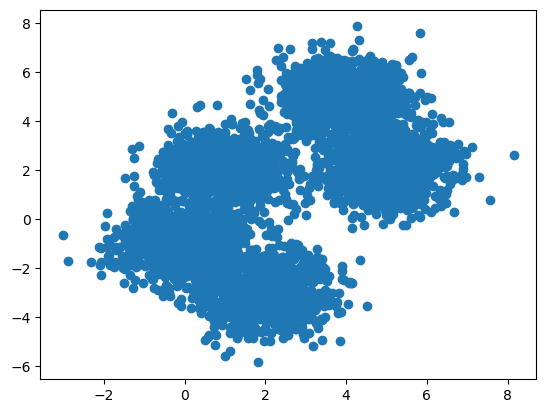

In [159]:
plt.scatter(x_blob[:, 0], x_blob[:, 1])

In [160]:
err=[]
mycluster =np.arange(2,50)
for ii in mycluster:
    model = KMeans(n_clusters=ii)
    model.fit(x_blob)
    err.append(model.inertia_)

Text(0, 0.5, 'Error')

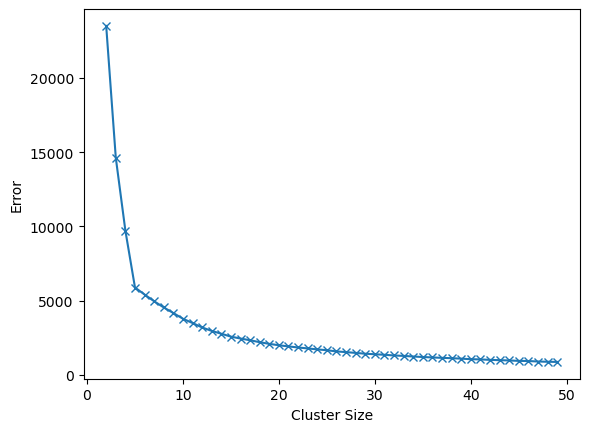

In [161]:
plt.plot(mycluster,err, marker = "x")
plt.xlabel('Cluster Size')
plt.ylabel('Error')

In [162]:
from sklearn.metrics import silhouette_score

for jj in mycluster:
    model = KMeans(n_clusters=jj, random_state = 42)
    model.fit(x_blob)
    sil_avg = silhouette_score(x_blob, model.labels_)
    print("For n_clusters =", jj, "The average silhouette_score is :", sil_avg)

For n_clusters = 2 The average silhouette_score is : 0.5143796585656915
For n_clusters = 3 The average silhouette_score is : 0.47883347929716963
For n_clusters = 4 The average silhouette_score is : 0.5170435500085796
For n_clusters = 5 The average silhouette_score is : 0.5363136975254452
For n_clusters = 6 The average silhouette_score is : 0.48160493253198833
For n_clusters = 7 The average silhouette_score is : 0.41386986062744163
For n_clusters = 8 The average silhouette_score is : 0.361706882747216
For n_clusters = 9 The average silhouette_score is : 0.3475414438927885
For n_clusters = 10 The average silhouette_score is : 0.31489739498245034
For n_clusters = 11 The average silhouette_score is : 0.3207313311731575
For n_clusters = 12 The average silhouette_score is : 0.3246881102205224
For n_clusters = 13 The average silhouette_score is : 0.32526995656848723
For n_clusters = 14 The average silhouette_score is : 0.32919135190358734
For n_clusters = 15 The average silhouette_score is : 

SilhouetteVisualizer(ax=<Axes: >,
                     estimator=KMeans(n_clusters=49, random_state=42))

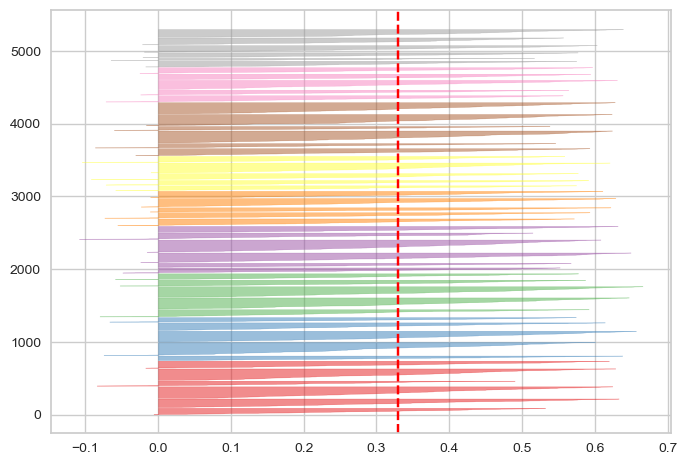

In [163]:
from yellowbrick.cluster import SilhouetteVisualizer
vis = SilhouetteVisualizer(model)
vis.fit(x_blob)

In [164]:
# final k is 5
final_km = KMeans(n_clusters=5, random_state=42)
final_km.fit(x_blob)
final_centroid = final_km.cluster_centers_
print("centroids are",final_centroid) # 5 cnetroids for 5 clusters
final_labels = final_km.labels_
print("final labels are", final_labels)# labels for each row
print("errors are",final_km.inertia_) # total of distortion

centroids are [[ 1.01449777  2.055272  ]
 [ 5.03936548  1.99615288]
 [ 2.04727041 -3.03426421]
 [ 3.95961045  5.01143455]
 [-0.08151584 -1.00795982]]
final labels are [2 0 1 ... 3 3 3]
errors are 5884.234669182054


SilhouetteVisualizer(ax=<Axes: >,
                     estimator=KMeans(n_clusters=5, random_state=42))

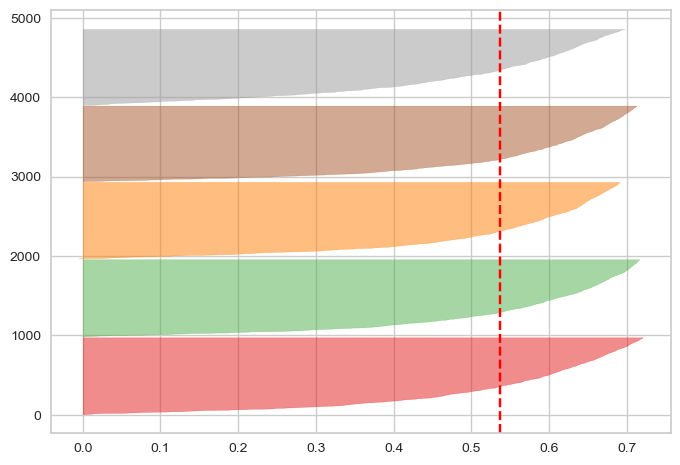

In [165]:
from yellowbrick.cluster import SilhouetteVisualizer
vis = SilhouetteVisualizer(final_km)
vis.fit(x_blob)

In [166]:
df2 = pd.DataFrame(x_blob)

In [167]:
df2

,0,1
0,2.276813,-3.195194
1,0.988974,3.208787
2,5.752216,1.124057
3,0.740100,-1.958674
4,0.939404,3.312252
...,...,...
4806,3.668406,5.519519
4807,0.193929,1.646719
4808,3.280537,4.967461
4809,3.386464,7.216516


In [168]:
df2['Group_Name'] = final_labels
df2

,0,1,Group_Name
0,2.276813,-3.195194,2
1,0.988974,3.208787,0
2,5.752216,1.124057,1
3,0.740100,-1.958674,4
4,0.939404,3.312252,0
...,...,...,...
4806,3.668406,5.519519,3
4807,0.193929,1.646719,0
4808,3.280537,4.967461,3
4809,3.386464,7.216516,3


In [169]:
mylabel = ["A", "B", "C", "D", "E"]

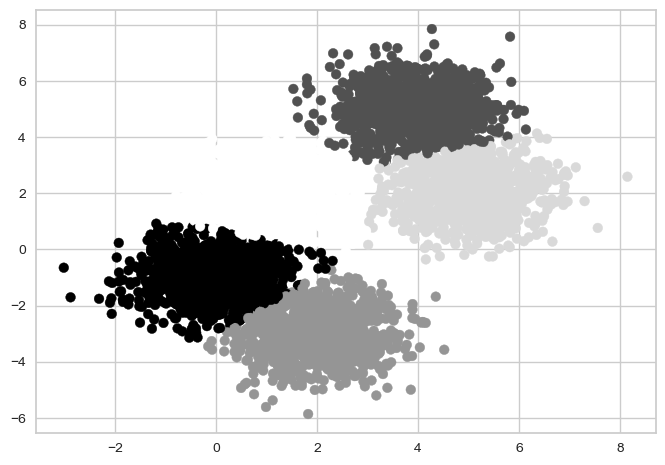

In [170]:
plt.scatter( x_blob[:,0], x_blob[:,1], label = mylabel, c = final_km.labels_)


Analysis: Overall, the K-means model demonstrated its ability to provide valuable insights into player groupings and can be used for further analysis and decision-making in the context of Football performance.